In [29]:
import polars as pl
import numpy as np

In [30]:
data = pl.read_csv("../data/cross_sell_email.csv")
data

gender,cross_sell_email,age,conversion
i64,str,i64,i64
0,"""short""",15,0
1,"""short""",27,0
1,"""long""",17,0
1,"""long""",34,0
1,"""no_email""",14,0
…,…,…,…
0,"""long""",18,0
1,"""no_email""",16,0
0,"""no_email""",15,0


In [31]:
data.group_by("cross_sell_email").agg(
    pl.col("gender", "age", "conversion").mean()
)

cross_sell_email,gender,age,conversion
str,f64,f64,f64
"""long""",0.550459,21.752294,0.055046
"""no_email""",0.542553,20.489362,0.042553
"""short""",0.633333,20.991667,0.125


In [32]:
import polars as pl

X = ["gender", "age"]

# Asumiendo que 'data' es tu DataFrame de Polars
result = (
    data.group_by("cross_sell_email")
    .agg([
        pl.col(c).mean().alias(f"{c}_mean") for c in X
    ] + [
        pl.col(c).var().alias(f"{c}_var") for c in X
    ])
    .with_columns([
        (
            (pl.col(f"{c}_mean") - pl.col(f"{c}_mean").filter(pl.col("cross_sell_email") == "no_email").first())
            /
            ((pl.col(f"{c}_var") + pl.col(f"{c}_var").filter(pl.col("cross_sell_email") == "no_email").first()) / 2).sqrt()
        ).alias(c) 
        for c in X
    ])
    .select(["cross_sell_email"] + X)
)

print(result)

shape: (3, 3)
┌──────────────────┬──────────┬──────────┐
│ cross_sell_email ┆ gender   ┆ age      │
│ ---              ┆ ---      ┆ ---      │
│ str              ┆ f64      ┆ f64      │
╞══════════════════╪══════════╪══════════╡
│ no_email         ┆ 0.0      ┆ 0.0      │
│ short            ┆ 0.184341 ┆ 0.08737  │
│ long             ┆ 0.015802 ┆ 0.221423 │
└──────────────────┴──────────┴──────────┘


In [33]:

df = pl.read_csv(r"..\data\enem_scores.csv")
df.sort(by="avg_score", descending=True).head(10)

year,school_id,number_of_students,avg_score
i64,i64,i64,f64
2007,33062633,68,82.97
2007,33065403,172,82.04
2005,33062633,59,81.89
2005,33065403,177,81.66
2007,29342880,43,80.32
2007,33152314,14,79.82
2007,33065250,80,79.67
2007,22025740,144,79.52
2007,31311723,222,79.41


In [34]:
q98 = df.select(pl.col('number_of_students').quantile(.98)).item()

data_plot = (
    df.with_columns(
        top_schools=pl.col("avg_score") >= pl.col("avg_score").quantile(0.99)
    )
    .filter(pl.col("number_of_students") < q98)
    .select(["avg_score", "number_of_students", "top_schools"])
)
data_plot

avg_score,number_of_students,top_schools
f64,i64,bool
69.03,144,false
57.82,184,false
64.83,220,false
51.69,51,false
50.16,47,false
…,…,…
59.81,177,false
73.18,131,true
57.61,131,false


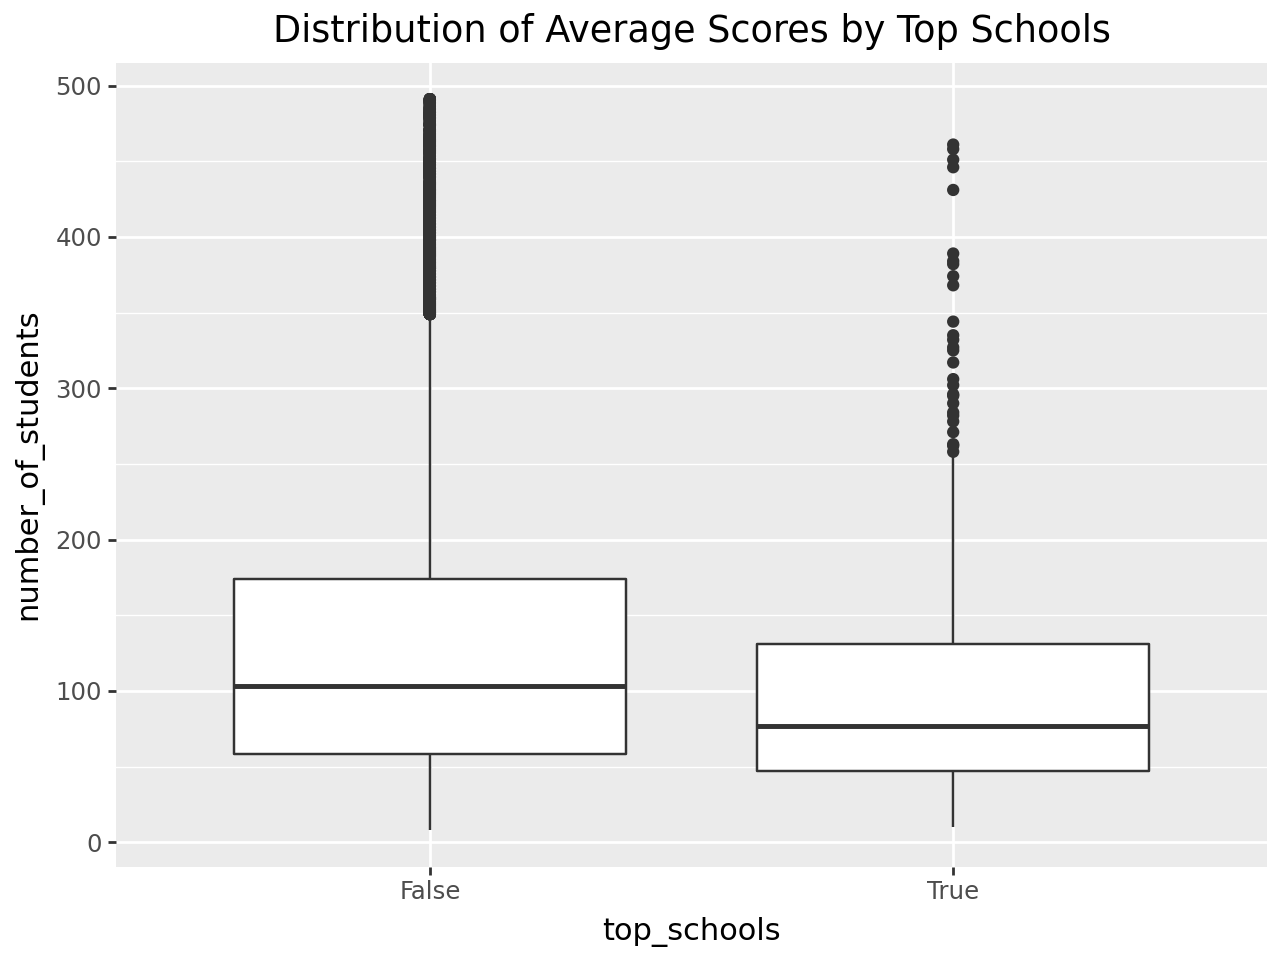

In [35]:
from plotnine import *

(
    ggplot(data_plot, aes(x="top_schools", y="number_of_students")) +
    geom_boxplot( ) +
    labs(title="Distribution of Average Scores by Top Schools") 
)

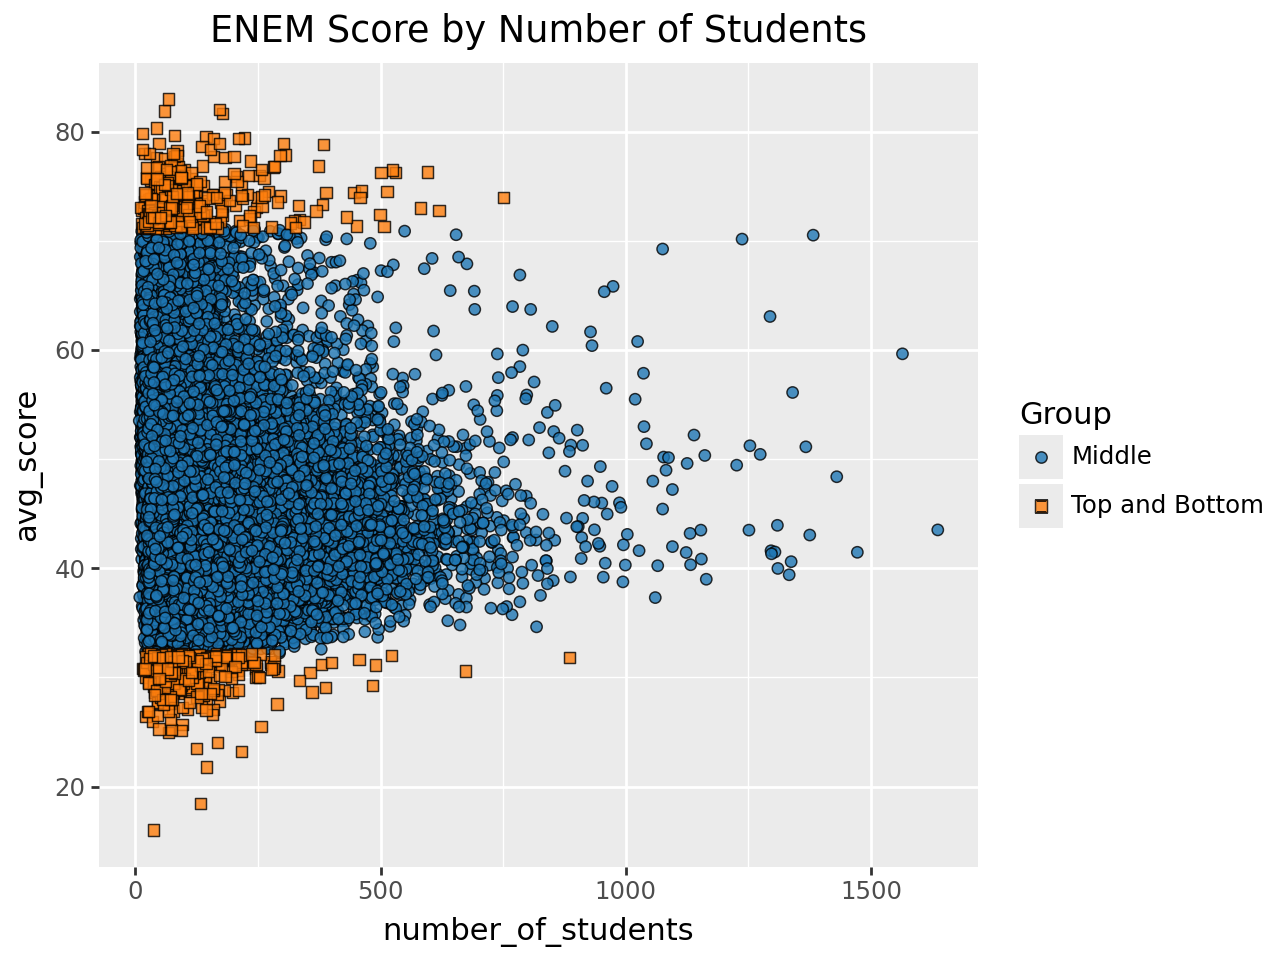

In [36]:
q01 = df.select(pl.col('avg_score').quantile(.01)).item()
q99 = df.select(pl.col('avg_score').quantile(.99)).item()

data_plot = (
    df.with_columns(
        pl.when((pl.col("avg_score") > q99) | (pl.col("avg_score") < q01))
          .then(pl.lit("Top and Bottom"))
          .otherwise(pl.lit("Middle"))
          .alias("Group")
    )
    .select(["avg_score", "number_of_students", "Group"])
)

from plotnine import *


(
    ggplot(data_plot, aes(x="number_of_students", y="avg_score", shape="Group", fill="Group"))
    + geom_point(color="black", size=2, stroke=0.3, alpha=0.8)
    # CORRECCIÓN: Usa strings ('o', 's') en lugar de enteros (21, 22)
    + scale_shape_manual(values=['o', 's']) 
    + scale_fill_manual(values=["#1f77b4", "#ff7f0e"])
    + labs(title="ENEM Score by Number of Students")
)

# Resumen: ecuación de Moivre (Error estándar de la media)

Explicación simple (EL5)  
Imagina que repetimos un experimento muchas veces y calculamos el promedio cada vez. Esos promedios no serán exactamente iguales: fluctúan. La ecuación de Moivre nos da una medida de cuánta variación esperar en ese promedio: el Error Estándar (SE).

Fórmula matemática
$$
SE = \frac{\sigma}{\sqrt{n}}
$$

Derivación breve y relación con la varianza  
La varianza del promedio muestral $\bar{X}$ es
$$
\mathrm{Var}(\bar{X})=\frac{\sigma^2}{n},
$$
por lo que el error estándar (la desviación típica de $\bar{X}$) es
$$
SE=\sqrt{\mathrm{Var}(\bar{X})}=\frac{\sigma}{\sqrt{n}}.
$$

Componentes (definiciones)
- $SE$: Error estándar de la media — cuánta incertidumbre hay en el promedio.  
- $\sigma$: desviación estándar de la población (si se desconoce, se usa la desviación muestral $s$).  
- $n$: tamaño de la muestra.

Intuición y consecuencias
- Si duplicas $n$, el SE se reduce por factor $\sqrt{2}$ (crecer $n$ tiene rendimientos decrecientes).  
- Si la dispersión $\sigma$ es mayor, el SE aumenta proporcionalmente.  
- Para intervalos de confianza (aprox. normal):
    $$
    \bar{x}\pm z_{0.975}\cdot SE\quad(\text{95\% aprox.})
    $$
    Si $\sigma$ es desconocida y $n$ pequeño, usar $t$ en lugar de $z$.

Ejemplo numérico
- Si $\sigma=10$ y $n=25$, entonces $SE=10/\sqrt{25}=2$.

Relevancia en inferencia causal  
El SE es central para evaluar si una diferencia de medias (por ejemplo, un ATE) es precisa o simplemente ruido. Para el ATE estimado $\widehat{\tau}$ se calcula su SE y con él construimos intervalos y pruebas de hipótesis. Recuerda también que estimadores sesgados o dependencias (autocorrelación, clustering) requieren fórmulas de SE ajustadas.

Nota histórica breve  
Abraham de Moivre contribuyó a los fundamentos del comportamiento asintótico de promedios y a la aproximación normal de la binomial; la expresión del SE como relación entre $\sigma$ y $\sqrt{n}$ es parte de ese marco probabilístico.


In [37]:
data = pl.read_csv("../data/cross_sell_email.csv")
data

gender,cross_sell_email,age,conversion
i64,str,i64,i64
0,"""short""",15,0
1,"""short""",27,0
1,"""long""",17,0
1,"""long""",34,0
1,"""no_email""",14,0
…,…,…,…
0,"""long""",18,0
1,"""no_email""",16,0
0,"""no_email""",15,0


In [38]:
short_email = data.filter(pl.col("cross_sell_email") == "short").select("conversion")
long_email = data.filter(pl.col("cross_sell_email") == "long").select("conversion")
no_email = data.filter(pl.col("cross_sell_email") == "no_email").select("conversion")
email = data.filter(pl.col("cross_sell_email") != "no_email").select("conversion")

data.group_by("cross_sell_email").len()

cross_sell_email,len
str,u32
"""long""",109
"""no_email""",94
"""short""",120


In [39]:
def se(y: pl.Series):
    return y.std() / np.sqrt(len(y))

print("SE for Long Email:", se(long_email))
print("SE for Short Email:", se(short_email))

SE for Long Email: shape: (1, 1)
┌────────────┐
│ conversion │
│ ---        │
│ f64        │
╞════════════╡
│ 0.021946   │
└────────────┘
SE for Short Email: shape: (1, 1)
┌────────────┐
│ conversion │
│ ---        │
│ f64        │
╞════════════╡
│ 0.030317   │
└────────────┘


## Confidence Intervals